# Course Scheduling — Exploratory Data Analysis

This notebook explores `data_teaching/` before you build the MILP scheduling model.

**What you will learn**
1. Size and structure of every table
2. Why room capacity is the tightest structural constraint
3. Which courses cannot share a timeslot (student or lecturer conflicts)
4. The cost landscape the optimiser navigates
5. Exact MILP dimensions (variables, constraints)

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    import networkx as nx
    HAS_NX = True
except ImportError:
    HAS_NX = False
    print('networkx not found — install with: pip install networkx')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('Libraries loaded.')

networkx not found — install with: pip install networkx
Libraries loaded.


In [2]:
DATA = 'data_teaching'

courses   = pd.read_csv(f'{DATA}/courses.csv')
rooms     = pd.read_csv(f'{DATA}/rooms.csv')
timeslots = pd.read_csv(f'{DATA}/timeslots.csv')
lecturers = pd.read_csv(f'{DATA}/lecturers.csv')
conflicts = pd.read_csv(f'{DATA}/course_conflicts.csv')
options   = pd.read_csv(f'{DATA}/course_period_options.csv')

tables = {
    'courses'              : courses,
    'rooms'                : rooms,
    'timeslots'            : timeslots,
    'lecturers'            : lecturers,
    'course_conflicts'     : conflicts,
    'course_period_options': options,
}

print('Files loaded:')
for name, df in tables.items():
    print(f'  {name:<25} {df.shape[0]:>4} rows x {df.shape[1]} cols')

n_vars = len(courses) * len(timeslots) * len(rooms)
print()
print(f'Decision variable space: |C|x|T|x|R| = {len(courses)}x{len(timeslots)}x{len(rooms)} = {n_vars} binary vars')

Files loaded:
  courses                     10 rows x 6 cols
  rooms                        5 rows x 4 cols
  timeslots                   15 rows x 5 cols
  lecturers                    8 rows x 2 cols
  course_conflicts             8 rows x 3 cols
  course_period_options        6 rows x 2 cols

Decision variable space: |C|x|T|x|R| = 10x15x5 = 750 binary vars


## 1. Courses

Each course is assigned **exactly one** (timeslot, room) pair.

| Column | Meaning |
|--------|---------|
| `n_students` | Total enrolment |
| `capacity_needed` | Seats the assigned room must have |
| `preferred_period` | Soft preference (extension exercise) |
| `lecturer_id` | Used by constraint C5 (lecturer non-overlap) |

In [3]:
merged = courses.merge(lecturers, on='lecturer_id')
merged = merged[['course_id','name_x','n_students','capacity_needed',
                 'preferred_period','name_y']].copy()
merged.columns = ['ID','Course','Students','Cap needed','Pref period','Lecturer']
merged

,ID,Course,Students,Cap needed,Pref period,Lecturer
0,1,Math Analysis,35,35,P2,Prof. Nguyen Hong A.
1,2,Linear Algebra,28,28,P2,Prof. Tran Hoang B.
2,3,Programming 101,40,40,P1,Prof. Le Duong C.
3,4,Data Structures,22,22,P3,Prof. Pham Nhat D.
4,5,AI Fundamentals,30,30,P2,Prof. Hoang Tri E.
5,6,Databases,18,18,P4,Prof. Le Duong C.
6,7,Networks,25,25,P3,Prof. Vo Trung F.
7,8,OS Concepts,20,20,P3,Prof. Dang Vu G.
8,9,Statistics,15,15,P3,Prof. Nguyen Hong A.
9,10,ML Basics,35,35,P2,Prof. Bui My H.


## 2. Room–Course Sizing

Constraint **C3** (room capacity ≥ class size) is structurally the tightest:
some courses fit in only one or two rooms, which hard-limits scheduling flexibility.

Bars = seats each course needs; vertical lines = the five room capacity thresholds.

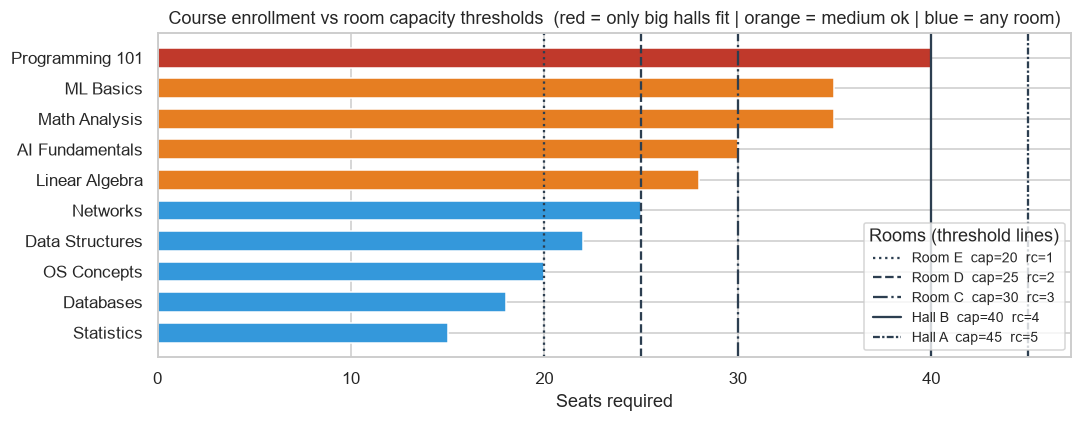


Course                 Cap needed  Eligible rooms
------------------------------------------------------------
Statistics                     15  Hall A, Hall B, Room C, Room D, Room E
Databases                      18  Hall A, Hall B, Room C, Room D, Room E
OS Concepts                    20  Hall A, Hall B, Room C, Room D, Room E
Data Structures                22  Hall A, Hall B, Room C, Room D
Networks                       25  Hall A, Hall B, Room C, Room D
Linear Algebra                 28  Hall A, Hall B, Room C
AI Fundamentals                30  Hall A, Hall B, Room C
Math Analysis                  35  Hall A, Hall B  <<  only 2 rooms
ML Basics                      35  Hall A, Hall B  <<  only 2 rooms
Programming 101                40  Hall A, Hall B  <<  only 2 rooms


In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

df = courses.sort_values('capacity_needed').reset_index(drop=True)
bar_clr = ['#c0392b' if v > 35 else '#e67e22' if v > 25 else '#3498db'
           for v in df['capacity_needed']]
ax.barh(df['name'], df['capacity_needed'], color=bar_clr, edgecolor='white', height=0.65)

room_s = rooms.sort_values('capacity')
styles = [':', '--', '-.', '-', (0, (3, 1, 1, 1))]
for (_, row), ls in zip(room_s.iterrows(), styles):
    rname = row['name']
    rcap  = row['capacity']
    rcost = row['cost_per_slot']
    ax.axvline(rcap, color='#2c3e50', linestyle=ls, linewidth=1.5,
               label=f'{rname}  cap={rcap}  rc={rcost}')

ax.set_xlabel('Seats required')
ax.set_title('Course enrollment vs room capacity thresholds  '
             '(red = only big halls fit | orange = medium ok | blue = any room)')
ax.legend(loc='lower right', fontsize=9, title='Rooms (threshold lines)')
plt.tight_layout()
plt.show()

# Eligibility table
print()
h1, h2 = 'Course', 'Cap needed'
print(f'{h1:<22} {h2:>10}  Eligible rooms')
print('-' * 60)
for _, c in df.iterrows():
    cname    = c['name']
    ccap     = int(c['capacity_needed'])
    eligible = rooms[rooms['capacity'] >= ccap]['name'].tolist()
    n        = len(eligible)
    flag     = '  <<<  only 1 room!' if n == 1 else '  <<  only 2 rooms' if n == 2 else ''
    estr     = ', '.join(eligible)
    print(f'{cname:<22} {ccap:>10}  {estr}{flag}')

## 3. Timeslots & Cost Structure

The schedule uses **3 days × 5 periods = 15 timeslots** (Mon–Wed, P1–P5).

The MILP objective minimises total scheduling cost:

$$\min \sum_{c,t,r} \bigl(\mathrm{rc}[r] + \mathrm{tc}[t]\bigr) \cdot x_{c,t,r}$$

The heatmap shows the combined cost of every (room, period) pair.  
**Key tension**: large courses *must* use expensive rooms (C3 forces it); the optimiser also tries to prefer morning slots.

Timeslot structure:
period  P1  P2  P3  P4  P5
day                       
Mon      2   1   1   2   3
Tue      2   1   1   2   3
Wed      2   1   1   2   3

Period costs: P1=2, P2=1, P3=1, P4=2, P5=3  (lower = preferred)
Room costs  : {'Hall A': 5, 'Hall B': 4, 'Room C': 3, 'Room D': 2, 'Room E': 1}


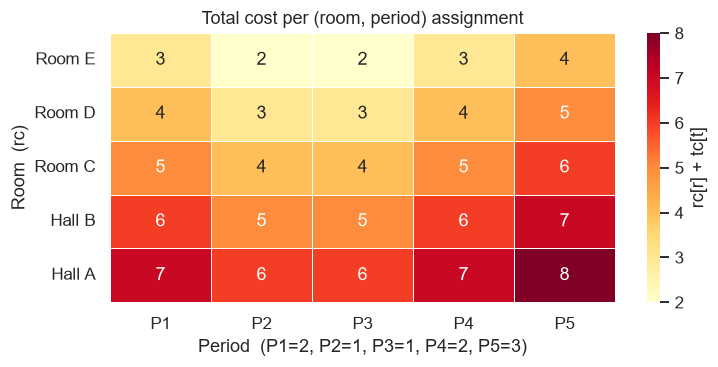

Cost range per assignment: 2 (cheapest) to 8 (costliest)


In [5]:
# Timeslot overview
print('Timeslot structure:')
print(timeslots.groupby(['day','period'])['cost'].first().unstack().to_string())
print()
print('Period costs: P1=2, P2=1, P3=1, P4=2, P5=3  (lower = preferred)')
print('Room costs  :', dict(zip(rooms['name'], rooms['cost_per_slot'])))

# Cost heatmap
periods      = ['P1','P2','P3','P4','P5']
period_cost  = {'P1': 2, 'P2': 1, 'P3': 1, 'P4': 2, 'P5': 3}

cost_matrix = pd.DataFrame(
    index=[r['name'] for _, r in rooms.iterrows()],
    columns=periods, dtype=float
)
for _, room in rooms.iterrows():
    for p in periods:
        cost_matrix.loc[room['name'], p] = room['cost_per_slot'] + period_cost[p]

cost_matrix = cost_matrix.sort_values('P2')  # cheapest room first

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(cost_matrix.astype(float), annot=True, fmt='.0f',
            cmap='YlOrRd', linewidths=0.5, ax=ax, vmin=2, vmax=8,
            cbar_kws={'label': 'rc[r] + tc[t]'})
ax.set_xlabel('Period  (P1=2, P2=1, P3=1, P4=2, P5=3)')
ax.set_ylabel('Room  (rc)')
ax.set_title('Total cost per (room, period) assignment')
plt.tight_layout()
plt.show()

lo = int(cost_matrix.min().min())
hi = int(cost_matrix.max().max())
print(f'Cost range per assignment: {lo} (cheapest) to {hi} (costliest)')

## 4. Student Conflict Graph

Two courses that share at least one student **cannot be scheduled at the same timeslot** (C4).
`course_conflicts.csv` is the pre-computed edge list of this constraint graph.

- **Node size** ∝ enrolment
- **Edge width** ∝ number of shared students
- **Node colour** = academic track

In [6]:
id2name = dict(zip(courses['course_id'].astype(int), courses['name']))

if HAS_NX:
    track_clr = {
        1: '#3498db', 2: '#3498db', 9: '#3498db',   # Math
        3: '#27ae60', 4: '#27ae60', 6: '#27ae60',   # CS / Programming
        5: '#e67e22', 10: '#e67e22',                 # AI / ML
        7: '#e74c3c', 8: '#e74c3c',                  # Systems
    }

    G = nx.Graph()
    for cid in courses['course_id'].astype(int):
        G.add_node(cid)
    for _, row in conflicts.iterrows():
        G.add_edge(int(row['course_a']), int(row['course_b']),
                   weight=int(row['shared_students']))

    size_d  = dict(zip(courses['course_id'].astype(int),
                       courses['n_students'] * 6 + 300))
    pos     = nx.spring_layout(G, seed=42, k=2.8)
    nsizes  = [size_d[n] for n in G.nodes()]
    ncolors = [track_clr.get(n, '#95a5a6') for n in G.nodes()]
    ewidths = [G[u][v]['weight'] / 4.0 for u, v in G.edges()]
    elabels = {(u, v): G[u][v]['weight'] for u, v in G.edges()}

    fig, axes = plt.subplots(1, 2, figsize=(13, 6),
                             gridspec_kw={'width_ratios': [3, 1]})
    ax = axes[0]
    nx.draw_networkx_nodes(G, pos, node_size=nsizes, node_color=ncolors,
                           alpha=0.9, ax=ax)
    nx.draw_networkx_edges(G, pos, width=ewidths, edge_color='#7f8c8d',
                           alpha=0.7, ax=ax)
    nx.draw_networkx_labels(G, pos, labels={n: str(n) for n in G.nodes()},
                            font_size=9, font_color='white',
                            font_weight='bold', ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=elabels,
                                 font_size=8, ax=ax)

    legend_h = [
        mpatches.Patch(color='#3498db', label='Math (1, 2, 9)'),
        mpatches.Patch(color='#27ae60', label='CS / Prog (3, 4, 6)'),
        mpatches.Patch(color='#e67e22', label='AI / ML (5, 10)'),
        mpatches.Patch(color='#e74c3c', label='Systems (7, 8)'),
    ]
    ax.legend(handles=legend_h, loc='upper left', fontsize=9)
    ax.set_title('Student conflict graph — node label = course ID, edge = shared students')
    ax.axis('off')

    axes[1].axis('off')
    tbl_rows = [[str(int(r['course_id'])), r['name']]
                for _, r in courses.iterrows()]
    tbl = axes[1].table(cellText=tbl_rows, colLabels=['ID', 'Course'],
                        loc='center', cellLoc='left')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.35)
    axes[1].set_title('Course index', pad=15)

    plt.tight_layout()
    plt.show()

    density = nx.density(G)
    print(f'Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}  |  Graph density: {density:.2f}')
    print(f'(Maximum possible edges for 10 nodes = {10*9//2})')

else:
    print('Conflict pairs (install networkx for the graph view):')
    for _, row in conflicts.iterrows():
        ca = int(row['course_a'])
        cb = int(row['course_b'])
        sh = int(row['shared_students'])
        print(f'  {id2name[ca]} <-> {id2name[cb]}  ({sh} shared students)')

Conflict pairs (install networkx for the graph view):
  Math Analysis <-> Linear Algebra  (15 shared students)
  Math Analysis <-> Statistics  (10 shared students)
  Linear Algebra <-> AI Fundamentals  (12 shared students)
  Programming 101 <-> Data Structures  (18 shared students)
  Programming 101 <-> Databases  (14 shared students)
  AI Fundamentals <-> ML Basics  (20 shared students)
  Networks <-> OS Concepts  (16 shared students)
  Data Structures <-> ML Basics  (8 shared students)


## 5. Lecturer Conflicts (C5)

A lecturer cannot teach two courses at the same timeslot.  
In this dataset **two lecturers** each teach two courses — these are the only binding C5 constraints.

In [7]:
lec_load = (
    courses.merge(lecturers, on='lecturer_id')
    .groupby(['lecturer_id', 'name_y'])['name_x']
    .apply(list)
    .reset_index()
)
lec_load.columns = ['Lec ID', 'Lecturer', 'Courses taught']

multi   = lec_load[lec_load['Courses taught'].apply(len) > 1].copy()
single  = (lec_load['Courses taught'].apply(len) == 1).sum()
multi['Courses taught'] = multi['Courses taught'].apply(lambda lst: '  |  '.join(lst))

print('Lecturers teaching TWO courses (generate C5 non-overlap constraints):')
print()
print(multi.to_string(index=False))
print()
print(f'Lecturers with one course (no C5 constraint): {single}')
n_lec_pairs = len(multi)
print(f'C5 inequalities added to the MILP           : {n_lec_pairs} pairs x {len(timeslots)} timeslots = {n_lec_pairs * len(timeslots)}')

Lecturers teaching TWO courses (generate C5 non-overlap constraints):

 Lec ID             Lecturer                Courses taught
      1 Prof. Nguyen Hong A.  Math Analysis  |  Statistics
      3    Prof. Le Duong C. Programming 101  |  Databases

Lecturers with one course (no C5 constraint): 6
C5 inequalities added to the MILP           : 2 pairs x 15 timeslots = 30


## 6. Period Restrictions (C6)

Two courses are restricted to a **subset of periods**; all others can use any period.  
Green = allowed, Red = forbidden.

| Course | Restriction | Rationale |
|--------|-------------|-----------|
| Databases | P3, P4, P5 only | Computer lab available from 09:30 |
| ML Basics | P1, P2, P3 only | Morning lecture slot required |

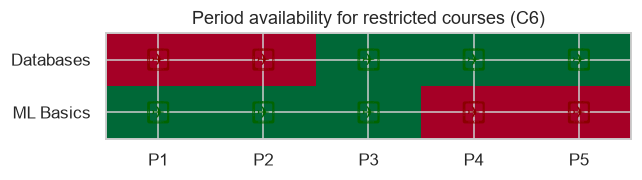

Unrestricted courses (8) — any period allowed:
  Math Analysis
  Linear Algebra
  Programming 101
  Data Structures
  AI Fundamentals
  Networks
  OS Concepts
  Statistics

C6 forbids 12 (course, timeslot) pairs = 12 x 5 = 60 variables fixed to 0


In [8]:
all_periods   = ['P1','P2','P3','P4','P5']
restricted_ids = options['course_id'].unique()

avail = pd.DataFrame(index=restricted_ids, columns=all_periods, dtype=int)
for cid in restricted_ids:
    allowed = options[options['course_id'] == cid]['period'].tolist()
    for p in all_periods:
        avail.loc[cid, p] = 1 if p in allowed else 0

avail.index = [id2name[cid] for cid in avail.index]

fig, ax = plt.subplots(figsize=(6, 1.8))
ax.imshow(avail.values.astype(float), cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(5))
ax.set_xticklabels(all_periods)
ax.set_yticks(range(len(avail)))
ax.set_yticklabels(avail.index)
check = chr(0x2713)
cross = chr(0x2717)
for (i, j), val in np.ndenumerate(avail.values):
    sym   = check if val else cross
    color = 'darkgreen' if val else 'darkred'
    ax.text(j, i, sym, ha='center', va='center', fontsize=15,
            fontweight='bold', color=color)
ax.set_title('Period availability for restricted courses (C6)')
plt.tight_layout()
plt.show()

unrestricted = courses[~courses['course_id'].isin(restricted_ids)]['name'].tolist()
print(f'Unrestricted courses ({len(unrestricted)}) — any period allowed:')
for c in unrestricted:
    print(f'  {c}')

n_forbidden = sum(
    len(timeslots[~timeslots['period'].isin(
        options[options['course_id'] == cid]['period'].tolist())])
    for cid in restricted_ids
)
print()
print(f'C6 forbids {n_forbidden} (course, timeslot) pairs '
      f'= {n_forbidden} x {len(rooms)} = {n_forbidden * len(rooms)} variables fixed to 0')

## 7. MILP Problem Summary

This section prints the dimensions of the model you will implement.  
It depends on `cost_matrix` defined in §3 and `n_forbidden` defined in §6 — run those cells first.

In [9]:
n_C = len(courses)
n_T = len(timeslots)
n_R = len(rooms)
n_E = len(conflicts)

lec_groups   = courses.groupby('lecturer_id')['course_id'].apply(list)
n_lec_pairs2 = sum(len(g) * (len(g) - 1) // 2 for g in lec_groups if len(g) > 1)

lo = int(cost_matrix.min().min())
hi = int(cost_matrix.max().max())

print('=' * 55)
print('  MILP PROBLEM DIMENSIONS')
print('=' * 55)
print(f'  Sets')
n_days    = len(timeslots['day'].unique())
n_periods = len(timeslots['period'].unique())
print(f'    |C| courses   : {n_C}')
print(f'    |T| timeslots : {n_T}  ({n_days} days x {n_periods} periods)')
print(f'    |R| rooms     : {n_R}')
print()
print(f'  Decision variables')
print(f'    x[c,t,r] in {{0,1}} : {n_C} x {n_T} x {n_R} = {n_C*n_T*n_R} binary variables')
print()
print(f'  Hard constraints')
print(f'    C1  assignment      : {n_C} equalities         (one per course)')
print(f'    C2  room conflict   : {n_T*n_R} inequalities   (one per timeslot-room pair)')
print(f'    C3  capacity        : pre-filter infeasible (c,r) pairs')
print(f'    C4  student clash   : {n_E} x {n_T} = {n_E*n_T} inequalities')
print(f'    C5  lecturer clash  : {n_lec_pairs2} x {n_T} = {n_lec_pairs2*n_T} inequalities')
print(f'    C6  period restrict : {n_forbidden} x {n_R} = {n_forbidden*n_R} variables fixed to 0')
print()
print(f'  Objective')
print(f'    min  sum_{{c,t,r}} (rc[r] + tc[t]) * x[c,t,r]')
print(f'    Cost per assignment: {lo} (cheapest) to {hi} (costliest)')
print()
print('  Extension: add preference penalty')
print('    min  sum_{{c,t,r}} (rc[r] + tc[t] + lam * pref_penalty[c,t]) * x[c,t,r]')
print('    where pref_penalty[c,t] = 1 if period(t) != preferred_period[c]')

  MILP PROBLEM DIMENSIONS
  Sets
    |C| courses   : 10
    |T| timeslots : 15  (3 days x 5 periods)
    |R| rooms     : 5

  Decision variables
    x[c,t,r] in {0,1} : 10 x 15 x 5 = 750 binary variables

  Hard constraints
    C1  assignment      : 10 equalities         (one per course)
    C2  room conflict   : 75 inequalities   (one per timeslot-room pair)
    C3  capacity        : pre-filter infeasible (c,r) pairs
    C4  student clash   : 8 x 15 = 120 inequalities
    C5  lecturer clash  : 2 x 15 = 30 inequalities
    C6  period restrict : 12 x 5 = 60 variables fixed to 0

  Objective
    min  sum_{c,t,r} (rc[r] + tc[t]) * x[c,t,r]
    Cost per assignment: 2 (cheapest) to 8 (costliest)

  Extension: add preference penalty
    min  sum_{{c,t,r}} (rc[r] + tc[t] + lam * pref_penalty[c,t]) * x[c,t,r]
    where pref_penalty[c,t] = 1 if period(t) != preferred_period[c]
